In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

# Reading chains

In [3]:
blind = True
fname_blind = '../output/blind-metacal-updatedcov/des-y3-2pt-blind-metacal-simcov.txt'
# 2pt only
blind_2pt = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-updatedcov/des-y3-2pt-blind-metacal-simcov.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)
# blind_2pt = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal/des-y3-2pt-blind-metacal.txt', to_mcsamples=True, blind=True)
# map3 only
blind_map3 = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-updatedcov/des-y3-map3-blind-metacal.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)
# joint all
blind_joint_all = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-cosmogridcutcov/des-y3-2pt-map3-all-blind-metacal.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)
# joint auto only
blind_joint_auto = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-updatedcov/des-y3-2pt-map3-auto.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)
# joint auto 334 344
blind_joint_auto_334_344 = utils.read_cosmosis_mcmc_des_chain('../output/blind-metacal-updatedcov/des-y3-2pt-map3-auto-334-344.txt', to_mcsamples=True, blind=blind, fname_mean=fname_blind)


Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in
Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in


## 2pt, map3 and joint

<Figure size 600x600 with 0 Axes>

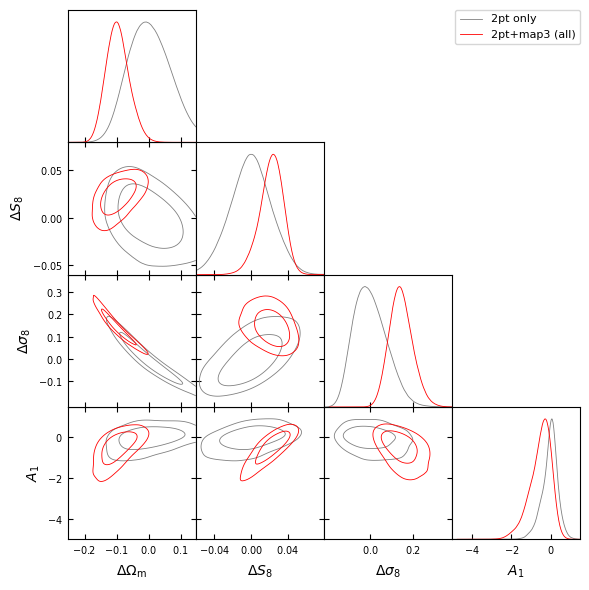

In [4]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([blind_2pt, blind_joint_all], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt only',  '2pt+map3 (all)'], legend_loc='upper right', 
    contour_colors=['gray', 'red'])
plt.show()

In [ ]:
import numpy as np

# Load the MCMC samples from your file
# Assuming your file is a space-separated text file with columns corresponding to parameters and log-posterior
data = np.loadtxt('../output/blind-metacal-updatedcov/des-y3-map3-blind-metacal.txt')

# Assuming the last column is the log-posterior
log_posterior = data[:, -1]
parameters = data[:, :-1]

# Find the index of the sample with the highest log-posterior
best_fit_index = np.argmax(log_posterior)
best_fit_params = parameters[best_fit_index]

print("Best-fit parameters:")
for i, param_value in enumerate(best_fit_params):
    print(f"Parameter {i}: {param_value:.5f}")

In [5]:
import numpy as np

# Load the MCMC samples from your file
# Assuming your file is a space-separated text file with columns corresponding to parameters and log-posterior
data = np.loadtxt('../output/blind-metacal/des-y3-2pt-map3-all-blind-metacal.txt')

# Assuming the last column is the log-posterior
log_posterior = data[:, -1]
parameters = data[:, :-1]

# Find the index of the sample with the highest log-posterior
best_fit_index = np.argmax(log_posterior)
best_fit_params = parameters[best_fit_index]

print("Best-fit parameters:")
for i, param_value in enumerate(best_fit_params):
    print(f"Parameter {i}: {param_value:.5f}")

Best-fit parameters:
Parameter 0: 0.29336
Parameter 1: 0.67244
Parameter 2: 0.04615
Parameter 3: 1.02235
Parameter 4: 0.78053
Parameter 5: 0.10176
Parameter 6: -0.00545
Parameter 7: -0.03393
Parameter 8: -0.03367
Parameter 9: -0.02756
Parameter 10: 0.01119
Parameter 11: -0.00774
Parameter 12: -0.00026
Parameter 13: 0.01268
Parameter 14: -0.84068
Parameter 15: 3.68660
Parameter 16: 0.78931
Parameter 17: 0.78479
Parameter 18: 248.18106
Parameter 19: 42.44906
Parameter 20: 29.70836
Parameter 21: -22.43018
Parameter 22: 7.27818


# increase in constraining power from 2pt to 2pt+map3(all)

<Figure size 600x600 with 0 Axes>

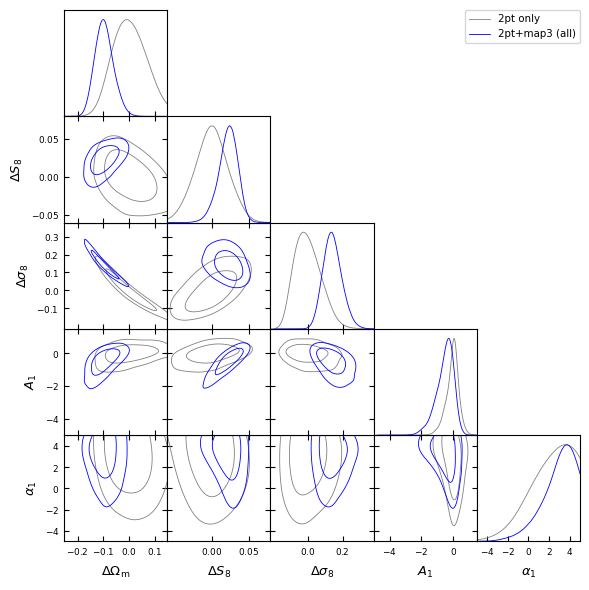

In [5]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([blind_2pt, blind_joint_all], ['om', 's8', 'sig8', 'a1', 'alpha1'], filled=False, \
    legend_labels=['2pt only','2pt+map3 (all)'], legend_loc='upper right', 
    contour_colors=['gray', 'blue'])
plt.show()

In [6]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint = utils.FoM_from_samples_names(blind_joint_all, ['om', 's8'])

print(fom_2pt, fom_joint)
print(fom_joint/fom_2pt)

796.8159863807681 2518.5164763587254
3.1607253360943766


# 2pt to 2pt+map3(auto only)

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([blind_2pt, blind_joint_auto], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt only','2pt+map3 (auto only)'], legend_loc='upper right', 
    contour_colors=['gray', 'blue'])
plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([blind_2pt, blind_joint_auto, blind_joint_all], 'om', 's8', filled=True, 
    colors=['gray', 'red', 'blue'], alphas=[0.7, 0.7, 0.7])
g.add_legend(['2pt', 'joint auto', 'joint all'], legend_loc='upper right')

In [ ]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(blind_joint_auto, ['om', 's8'])

print(fom_2pt, fom_joint_auto)
print(fom_joint_auto/fom_2pt)

In [ ]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(blind_joint_auto, ['om', 's8'])

print(fom_2pt, fom_joint_auto_334_344)
print(fom_joint_auto_334_344/fom_2pt)

# 2pt vs 2pt+map3(auto+334+344)

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([blind_2pt, blind_joint_auto_334_344, blind_joint_all], 'om', 's8', filled=True, 
    colors=['gray', 'green', 'blue'], alphas=[0.7, 0.7, 0.7])
g.add_legend(['2pt', 'joint auto+334+344', 'joint all'], legend_loc='upper right')

In [ ]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto_334_344 = utils.FoM_from_samples_names(blind_joint_auto_334_344, ['om', 's8'])

print(fom_2pt, fom_joint_auto_334_344)
print(fom_joint_auto_334_344/fom_2pt)

### Summary in one plot

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([blind_2pt, blind_joint_auto, blind_joint_auto_334_344, blind_joint_all], 'om', 's8', filled=True, 
    colors=['gray', 'red', 'green', 'blue'], alphas=[0.8, 0.8, 0.8])
g.add_legend(['2pt', 'joint auto', 'joint auto+334+344', 'joint all'], legend_loc='upper right')

In [ ]:
import pandas as pd

fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(blind_joint_auto, ['om', 's8'])
fom_joint_auto_334_344 = utils.FoM_from_samples_names(blind_joint_auto_334_344, ['om', 's8'])
fom_joint_all = utils.FoM_from_samples_names(blind_joint_all, ['om', 's8'])

data = {'Analysis': ['2pt only', '2pt+map3 (auto only)', '2pt+map3 (auto+334+344)', '2pt+map3 (all)'],
    'FoM': [fom_2pt, fom_joint_auto, fom_joint_auto_334_344, fom_joint_all],
    'Ratio to 2pt': [1, fom_joint_auto/fom_2pt, fom_joint_auto_334_344/fom_2pt, fom_joint_all/fom_2pt]}

df = pd.DataFrame(data)
df

# Theory vs Data vector at Signal level

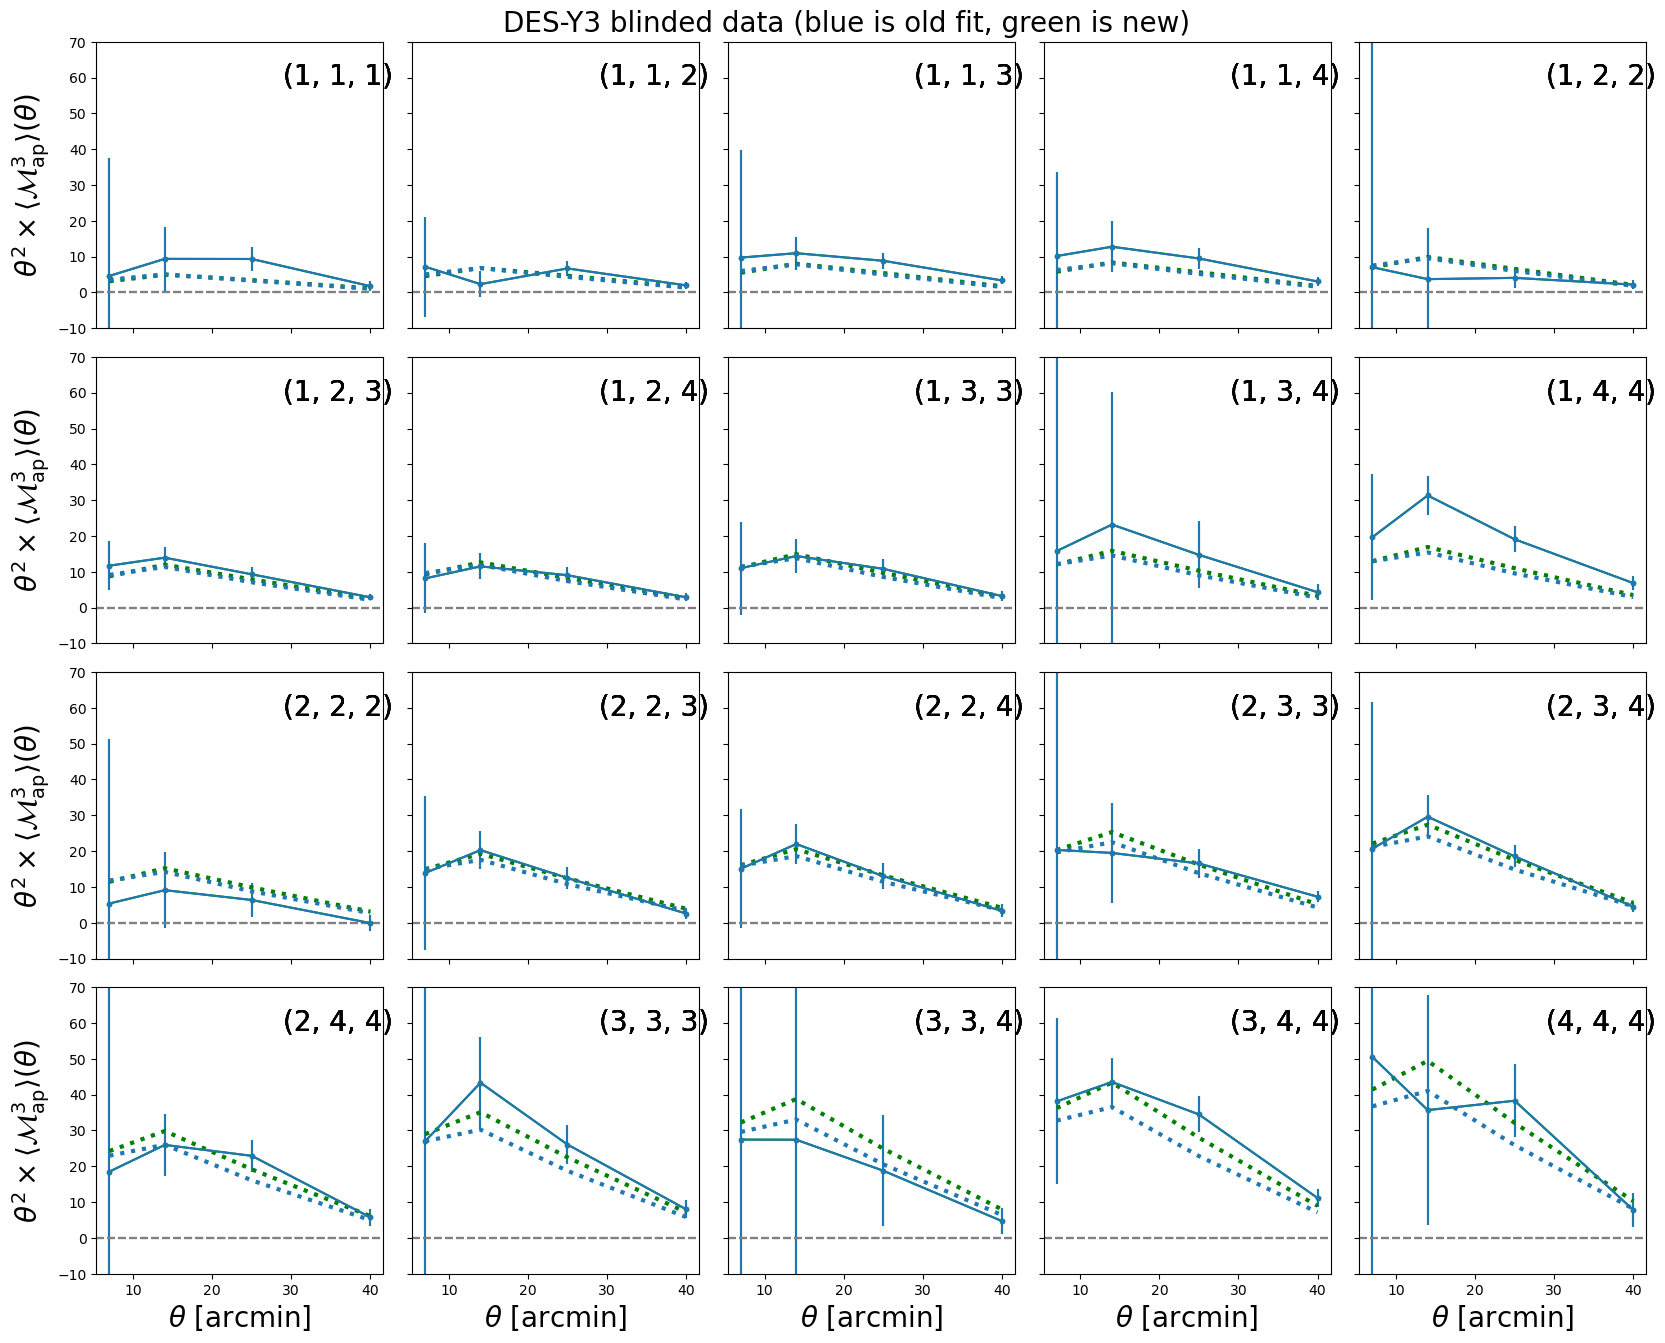

In [22]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/real_map3_desy3_blind_weightedcov.fits')
line_args = dict(color='g', ls='-')
fig, axes = thpt.plot2d(4, 5, figsize=(20, 16), title='DES-Y3 blinded data (blue is old fit, green is new)', **line_args)
thpt_oldcov = threepoint.ThreePointDataClass.from_fits('../data/dv/real_map3_desy3_blind.fits')
line_args = dict(color='C0', ls='-')
fig, axes = thpt_oldcov.plot2d(4, 5, figaxes=(fig, axes), **line_args)
thpt_bf = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-emu-blindY3-BESTFIT.fits')
line_args = dict(color='g', lw=3, ls=':', label='new fit')
fig, axes = thpt_bf.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args)
thpt_bf_old = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-emu-blindY3-oldcov-BESTFIT.fits')
line_args = dict(color='C0', lw=3, ls=':', label='old fit')
fig, axes = thpt_bf_old.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args)
#fig.savefig('../plots/signal-blind-map3-vs-two_bestfits.pdf', bbox_inches='tight')

## Testing chi2 values as a function of scale and z

In [14]:
for Rmin in [7,14,25, 40]:
    # 
    data = thpt.get_signal()
    theo = thpt_bf.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    R    = thpt.get_t_bin()[0]
    #
    sel  = R>=Rmin
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

27.697/80=0.346
23.466/60=0.391
15.962/40=0.399
8.834/20=0.442


In [13]:
#old bestfit, new cov
for Rmin in [7,14,25, 40]:
    # 
    data = thpt.get_signal()
    theo = thpt_bf_old.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    R    = thpt.get_t_bin()[0]
    #
    sel  = R>=Rmin
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

29.863/80=0.373
25.768/60=0.429
17.906/40=0.448
9.434/20=0.472


In [ ]:
for Rmax in [7,14,25, 40]:
    # 
    data = thpt.get_signal()
    theo = thpt_bf.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    R    = thpt.get_t_bin()[0]
    #
    sel  = R<=Rmax
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [ ]:
for i in range(20):
    # 
    data = thpt.get_signal()
    theo = thpt_bf.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    # print(np.unique(R))
    #
    sel  = np.arange(4*i, 4*(i+1), 1)
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov)
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [ ]:
data = thpt.get_signal()
theo = thpt_bf.get_signal()
diff = data - theo
cov  = thpt.get_covariance()
cov  = np.diag(np.diag(cov)) # Take only diagonal
R    = thpt.get_t_bin()[0]
# 
f = (400-diff.size-2)/(400-1)
icov = np.linalg.inv(cov) * f
chi2 = diff.dot(icov).dot(diff)
dof  = diff.size
print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [9]:
#VIEW 2pt BLIND FILE
from astropy.io import fits
view = fits.open('../data/dv/blind-metacal-2pt-DESY3-SimCov-weighted.fits')
view.info()

Filename: ../data/dv/blind-metacal-2pt-DESY3-SimCov-weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
